100%|██████████| 9.91M/9.91M [00:00<00:00, 16.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 408kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.76MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.4MB/s]
Epoch 1/20: 100%|██████████| 469/469 [00:13<00:00, 35.49it/s, loss=0.0779]


Epoch 1: 0.134132


Epoch 2/20: 100%|██████████| 469/469 [00:12<00:00, 37.47it/s, loss=0.0725]


Epoch 2: 0.075090


Epoch 3/20: 100%|██████████| 469/469 [00:11<00:00, 40.49it/s, loss=0.0755]


...

Epoch 18: 0.070226


Epoch 19/20: 100%|██████████| 469/469 [00:11<00:00, 40.26it/s, loss=0.0720]


Epoch 19: 0.070174


Epoch 20/20: 100%|██████████| 469/469 [00:11<00:00, 39.90it/s, loss=0.0702]


Epoch 20: 0.070173


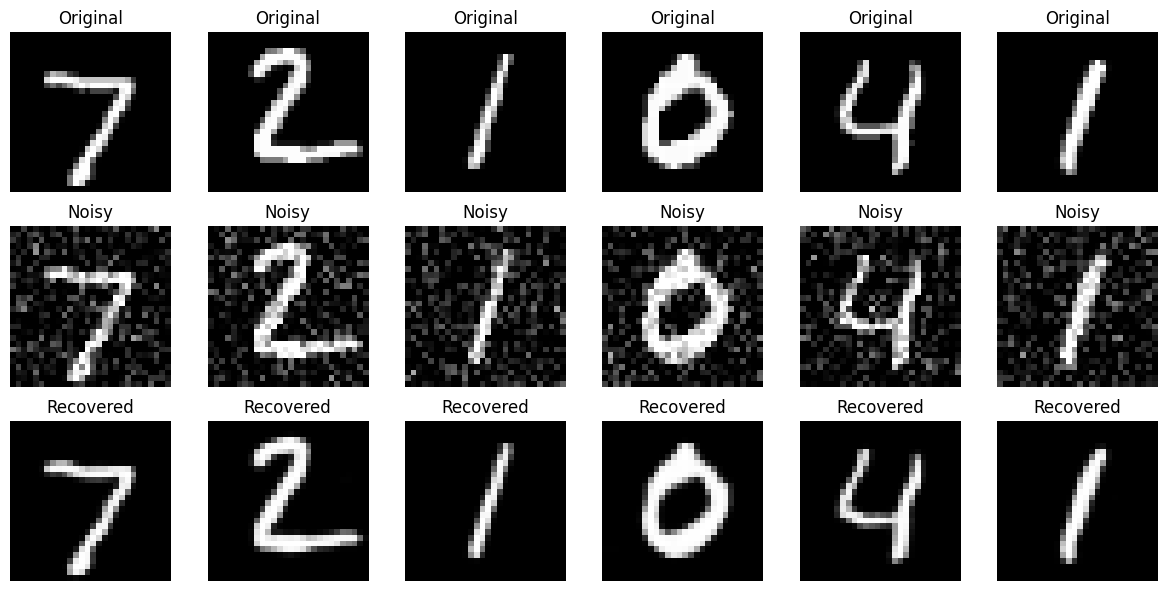

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 128
LR = 1e-3
EPOCHS = 20

transform = transforms.ToTensor()

train_ds = MNIST("./data", train=True, download=True, transform=transform)
test_ds = MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

def add_noise(x, std=0.2):
    noise = torch.randn_like(x) * std
    return torch.clamp(x + noise, 0., 1.)

class DenoisingAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.MaxPool2d(2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64,32,2,stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32,16,2,stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16,1,3,padding=1),
            nn.Sigmoid()
        )
    def forward(self,x):
        return self.decoder(self.encoder(x))

model = DenoisingAutoEncoder().to(DEVICE)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

best = 1e9

for epoch in range(EPOCHS):
    model.train()
    running = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for clean,_ in loop:
        clean = clean.to(DEVICE)
        noisy = add_noise(clean)
        out = model(noisy)
        loss = criterion(out, clean)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")
    epoch_loss = running/len(train_loader)
    scheduler.step(epoch_loss)
    print(f"Epoch {epoch+1}: {epoch_loss:.6f}")
    if epoch_loss < best:
        best = epoch_loss
        torch.save(model.state_dict(),"best_denoising_autoencoder.pth")

model.load_state_dict(torch.load("best_denoising_autoencoder.pth", map_location=DEVICE))
model.eval()

imgs,_ = next(iter(test_loader))
imgs = imgs.to(DEVICE)
noisy = add_noise(imgs)

with torch.no_grad():
    rec = model(noisy)

imgs = imgs.cpu()
noisy = noisy.cpu()
rec = rec.cpu()

plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(3,6,i+1)
    plt.imshow(imgs[i,0], cmap="gray")
    plt.axis("off")
    plt.title("Original")

    plt.subplot(3,6,6+i+1)
    plt.imshow(noisy[i,0], cmap="gray")
    plt.axis("off")
    plt.title("Noisy")

    plt.subplot(3,6,12+i+1)
    plt.imshow(rec[i,0], cmap="gray")
    plt.axis("off")
    plt.title("Recovered")

plt.tight_layout()
plt.show()


In [2]:
import torch

torch.save(model.state_dict(), "denoising_autoencoder.pth")

print("Model saved successfully!")

Model saved successfully!
